# Risk Attribution: Menchero Methodology ###

In [1]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from factors_toolkit import FamaFrenchFactors
from markowitz_portfolios_toolkit import markowitz_weights
from markowitz_portfolios_toolkit import portfolio_variance

### Building a Portfolio ###

In [2]:
tickers = get_tickers("6.3")

tickers

['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']

In [3]:
# Import the Returns Data
returns_df = pd.read_csv(r'../additional_data/stocks_returns.csv')
returns_df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
returns_df.set_index('Date', inplace=True)
returns_df.index = pd.to_datetime(returns_df.index)

returns_df

,A,AAL,AAP,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,...,XEL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,NaN,NaN,NaN,0.048789,NaN,NaN,0.001281,-0.039193,NaN,-0.021506,...,0.002275,-0.008643,0.009709,0.018928,NaN,0.019293,NaN,0.016878,-0.003114,NaN
1999-01-06,NaN,NaN,NaN,-0.036742,NaN,NaN,-0.007712,0.000000,NaN,-0.036462,...,0.004535,0.039154,0.009615,0.019087,NaN,0.015170,NaN,0.002090,0.001039,NaN
1999-01-07,NaN,NaN,NaN,0.074963,NaN,NaN,-0.012987,-0.005831,NaN,0.020998,...,-0.004535,-0.001670,-0.002395,-0.004610,NaN,-0.005031,NaN,0.022705,-0.007295,NaN
1999-01-08,NaN,NaN,NaN,0.000000,NaN,NaN,-0.003929,-0.005865,NaN,0.014185,...,-0.006841,-0.005870,-0.012063,-0.004631,NaN,0.002519,NaN,0.104544,0.002090,NaN
1999-01-11,NaN,NaN,NaN,0.019256,NaN,NaN,-0.013211,-0.048202,NaN,0.003834,...,-0.023150,-0.042085,-0.032062,0.014337,NaN,0.026073,NaN,-0.045120,-0.027515,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011082,0.005780,-0.000457,0.011413,0.008985,0.003488,0.003929,0.006278,0.007940,0.002683,...,0.007210,0.000940,-0.002642,-0.023556,0.005432,0.008480,0.004484,0.012187,0.010791,0.002553
2024-12-26,-0.001986,0.000000,0.011595,0.003171,-0.004454,0.002442,0.004434,0.002802,-0.003324,0.004944,...,-0.000440,0.000845,0.013663,-0.006522,0.002705,0.007380,-0.000466,0.003559,0.006889,0.004966
2024-12-27,-0.002137,0.000000,-0.004077,-0.013331,-0.006663,-0.014403,-0.002432,-0.006369,-0.011862,-0.008208,...,-0.000587,-0.000094,-0.003163,-0.002183,-0.007966,-0.005678,-0.003549,-0.019799,-0.012179,-0.005574


In [4]:
# Make the portfolio DataFrame
portfolio_holdings_df = returns_df[tickers]
portfolio_holdings_df = portfolio_holdings_df

portfolio_holdings_df

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
Date,,,,,,,
1999-01-05,0.048789,0.050976,NaN,NaN,0.038266,NaN,NaN
1999-01-06,-0.036742,0.102948,NaN,NaN,0.031908,NaN,NaN
1999-01-07,0.074963,0.140864,NaN,NaN,-0.004971,NaN,NaN
1999-01-08,0.000000,0.008617,NaN,NaN,-0.004162,NaN,NaN
1999-01-11,0.019256,0.141592,NaN,NaN,-0.015973,NaN,NaN
...,...,...,...,...,...,...,...
2024-12-24,0.011413,0.017573,0.008029,0.013084,0.009330,0.003930,0.070991
2024-12-26,0.003171,-0.008770,-0.002382,-0.007266,-0.002781,-0.002070,-0.017787
2024-12-27,-0.013331,-0.014641,-0.015647,-0.005885,-0.017453,-0.021088,-0.050745


In [5]:
# Portfolio's Returns and Variances
expected_returns = portfolio_holdings_df.mean()
covariance_matrix = portfolio_holdings_df.cov()

In [6]:
# Obtain Weights
p_weights = markowitz_weights(
    expected_returns, 
    covariance_matrix,
    0.0015
)

p_weights

array([ 0.40205898, -0.07613294,  0.53946463,  0.17977352, -0.60790589,
        0.1899289 ,  0.3728128 ])

In [7]:
# Create a Portfolio Weights DF
portfolio_weights = pd.Series(
    p_weights,
    index = portfolio_holdings_df.columns,
    name = 'weights'
)

portfolio_weights

AAPL    0.402059
AMZN   -0.076133
GOOG    0.539465
META    0.179774
MSFT   -0.607906
NVDA    0.189929
TSLA    0.372813
Name: weights, dtype: float64

In [8]:
# Portfolios Variance
p_variance = portfolio_variance(p_weights, portfolio_holdings_df)

p_variance

0.0006490146573267748

In [9]:
# Portfolio Returns
portfolio_returns = portfolio_holdings_df @ p_weights
portfolio_returns.name = 'portfolio_returns'

In [10]:
# Holdings Standard Deviations
holdings_stds = portfolio_holdings_df.std()

holdings_stds

AAPL    0.025823
AMZN    0.032661
GOOG    0.019177
META    0.025121
MSFT    0.019236
NVDA    0.037613
TSLA    0.035985
dtype: float64

In [11]:
# Holding's correlations with the portfolio
corr_with_portfolio = portfolio_holdings_df.corrwith(portfolio_returns)

corr_with_portfolio

AAPL    0.660792
AMZN    0.508984
GOOG    0.679479
META    0.575006
MSFT    0.427426
NVDA    0.620459
TSLA    0.808090
dtype: float64

The reader can review the derivation of the x-sigma-rho methodology in Section 3 of this module’s PDF.

In [12]:
# Now get the x-sigma-rho
RC = portfolio_weights * holdings_stds * corr_with_portfolio
RC.name = 'risk_contribution'

RC

AAPL    0.006861
AMZN   -0.001266
GOOG    0.007029
META    0.002597
MSFT   -0.004998
NVDA    0.004432
TSLA    0.010841
Name: risk_contribution, dtype: float64

In [13]:
RC.sum()

0.025496392388927442

In [14]:
np.sqrt(p_variance)

0.02547576607929141

In [15]:
# In percentage
RC_percent = (RC / np.sqrt(p_variance)) * 100

RC_percent

AAPL    26.929688
AMZN    -4.968041
GOOG    27.591910
META    10.193203
MSFT   -19.619446
NVDA    17.398652
TSLA    42.554997
Name: risk_contribution, dtype: float64

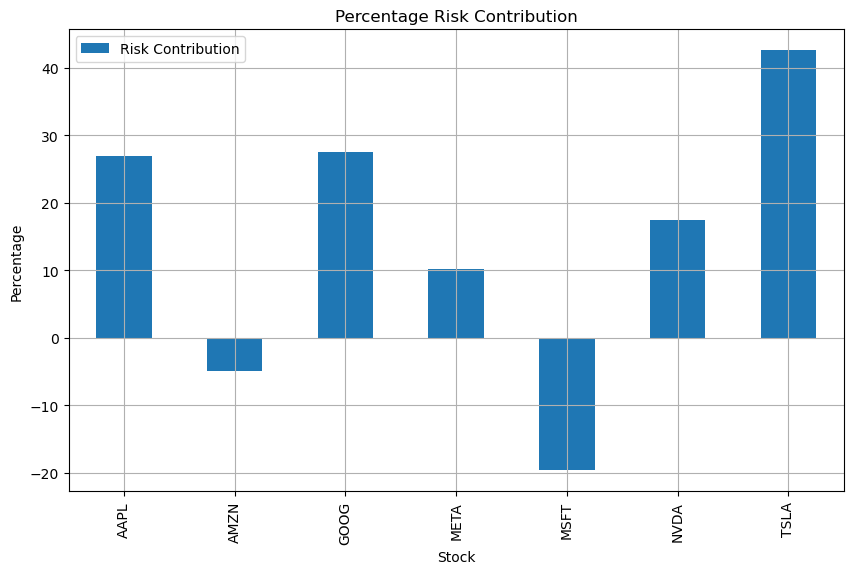

In [16]:
# Create Plot
plt.figure(figsize=(10, 6))
RC_percent.plot(kind='bar', label='Risk Contribution')

# Config
plt.title('Percentage Risk Contribution')
plt.xlabel('Stock')
plt.ylabel('Percentage')
plt.legend()
plt.grid()

# Show
plt.show() 

In [17]:
# Marginal Risk Contribution
MRC = holdings_stds * corr_with_portfolio
MRC.name = 'marginal_risk_contribution'

MRC

AAPL    0.017064
AMZN    0.016624
GOOG    0.013030
META    0.014445
MSFT    0.008222
NVDA    0.023337
TSLA    0.029080
Name: marginal_risk_contribution, dtype: float64

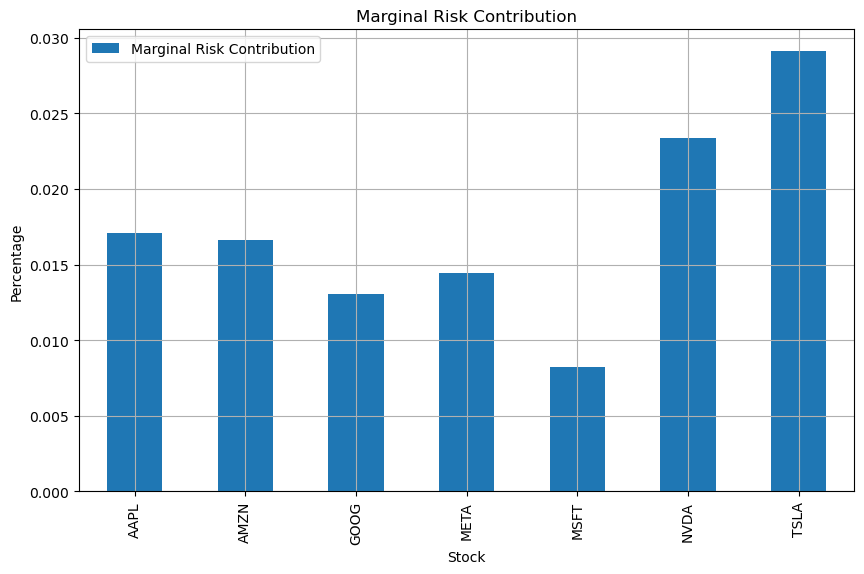

In [18]:
# Create Plot
plt.figure(figsize=(10, 6))
MRC.plot(kind='bar', label='Marginal Risk Contribution')

# Config
plt.title('Marginal Risk Contribution')
plt.xlabel('Stock')
plt.ylabel('Percentage')
plt.legend()
plt.grid()

# Show
plt.show() 

We conclude that our portfolio’s risk is more sensitive to NVDA’s exposure than to that of any other stock in the portfolio.

### Now Using Factor ###

In [22]:
# We can download the premiums in the Fama and French website
premiums_df = pd.read_csv(r'../additional_data/ff_size_n_value.csv')
premiums_df.set_index('date', inplace=True)
premiums_df.index = pd.to_datetime(premiums_df.index)
premiums_df.columns = ['mkt_premium', 'smb_premium', 'hml_premium']

premiums_df

,mkt_premium,smb_premium,hml_premium
date,,,
1999-01-04,-0.0018,0.0014,0.0045
1999-01-05,0.0110,-0.0074,-0.0007
1999-01-06,0.0211,-0.0058,-0.0059
1999-01-07,-0.0007,0.0050,-0.0030
1999-01-08,0.0045,0.0009,0.0027
...,...,...,...
2024-12-24,0.0111,-0.0009,-0.0006
2024-12-26,0.0001,0.0104,-0.0019
2024-12-27,-0.0117,-0.0065,0.0057


In [24]:
# Get the important data for the Risk-Free Rate
rfr = pd.read_csv(r"../additional_data/risk_free_rate.csv")
rfr.set_index('Date', inplace=True)
rfr.index = pd.to_datetime(rfr.index)

rfr

,risk_free_rate
Date,
1999-01-05,0.000131
1999-01-06,0.000131
1999-01-07,0.000132
1999-01-08,0.000135
1999-01-11,0.000135
...,...
2024-12-24,0.000128
2024-12-26,0.000127
2024-12-27,0.000128


In [25]:
# Now calculate the betas
portfolio_premium = portfolio_returns - rfr['risk_free_rate']

# Check if the Function Works
parameters = FamaFrenchFactors(
    portfolio_premium,
    premiums_df['mkt_premium'],
    premiums_df['smb_premium'],
    premiums_df['hml_premium'],
)

parameters

{'alpha': 0.0005159139033014347,
 'mkt_beta': 1.3363815474952652,
 'smb_beta': 0.26107021442567896,
 'hml_beta': -0.6260975722768752}

In [26]:
# Create the Parameters Series
portfolio_parameters = pd.DataFrame([parameters])
portfolio_parameters.columns = ['const', 'mkt_premium', 'smb_premium', 'hml_premium']
portfolio_parameters = portfolio_parameters.T
portfolio_parameters.columns = ['parameters']
portfolio_parameters = portfolio_parameters['parameters']
portfolio_parameters = portfolio_parameters.iloc[1:]

portfolio_parameters

mkt_premium    1.336382
smb_premium    0.261070
hml_premium   -0.626098
Name: parameters, dtype: float64

In [27]:
# Get the standard deviations of the premiums
premiums_std = premiums_df[['mkt_premium', 'smb_premium', 'hml_premium']].std()
premiums_std.name = 'premium_std'

premiums_std

mkt_premium    0.012348
smb_premium    0.006433
hml_premium    0.007793
Name: premium_std, dtype: float64

In [28]:
# Holding's correlations with the portfolio
factors_corr_with_portfolio = premiums_df[['mkt_premium', 'smb_premium', 'hml_premium']].corrwith(portfolio_returns)

factors_corr_with_portfolio

mkt_premium    0.659297
smb_premium    0.220663
hml_premium   -0.268214
dtype: float64

In [29]:
# Now get the x-sigma-rho
RC = portfolio_parameters * premiums_std * factors_corr_with_portfolio
RC.name = 'risk_contribution'

RC

mkt_premium    0.010879
smb_premium    0.000371
hml_premium    0.001309
Name: risk_contribution, dtype: float64

In [30]:
RC.sum()

0.012558386096779051

In [31]:
np.sqrt(portfolio_returns.var()) - RC.sum()

0.010015004415721208

In [32]:
# In percentage
RC_percent = (RC / np.sqrt(p_variance)) * 100

RC_percent

mkt_premium    42.703598
smb_premium     1.454761
hml_premium     5.137063
Name: risk_contribution, dtype: float64

In [33]:
# Idiosyncratic Risk
idio_risk = 100 - RC_percent.sum()
idio_risk

50.704579176571116

### Correlation Drilldown ###

In Section 3 of the PDF, the correlation drilldown is explored in greater depth and with more mathematical rigor

In [34]:
# Calculate the Sigmas
sigmas = portfolio_holdings_df.std()

sigmas

AAPL    0.025823
AMZN    0.032661
GOOG    0.019177
META    0.025121
MSFT    0.019236
NVDA    0.037613
TSLA    0.035985
dtype: float64

In [35]:
# The Covariances
gammas = portfolio_holdings_df.cov()

gammas

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
AAPL,0.000667,0.000300,0.000203,0.000189,0.000227,0.000384,0.000226
AMZN,0.000300,0.001067,0.000237,0.000257,0.000270,0.000408,0.000261
GOOG,0.000203,0.000237,0.000368,0.000231,0.000184,0.000264,0.000206
META,0.000189,0.000257,0.000231,0.000631,0.000197,0.000299,0.000253
MSFT,0.000227,0.000270,0.000184,0.000197,0.000370,0.000335,0.000205
NVDA,0.000384,0.000408,0.000264,0.000299,0.000335,0.001415,0.000374
TSLA,0.000226,0.000261,0.000206,0.000253,0.000205,0.000374,0.001295


In [36]:
# Portfolio Sigma
sigma_P = np.sqrt(p_variance)

sigma_P

0.02547576607929141

In [37]:
# The Correlations
rhos = portfolio_holdings_df.corr()

rhos

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
AAPL,1.000000,0.355156,0.518433,0.426979,0.456862,0.396617,0.359908
AMZN,0.355156,1.000000,0.519732,0.507602,0.429571,0.335523,0.353833
GOOG,0.518433,0.519732,1.000000,0.537668,0.565637,0.449841,0.333459
META,0.426979,0.507602,0.537668,1.000000,0.475849,0.423782,0.281880
MSFT,0.456862,0.429571,0.565637,0.475849,1.000000,0.463501,0.352437
NVDA,0.396617,0.335523,0.449841,0.423782,0.463501,1.000000,0.366242
TSLA,0.359908,0.353833,0.333459,0.281880,0.352437,0.366242,1.000000


In [38]:
# Let us check the drilldowns
decomp = pd.DataFrame(index=portfolio_holdings_df.columns, columns=portfolio_holdings_df.columns)

# Loop
for m in portfolio_holdings_df.columns:  # Stock m (rows)
    for n in portfolio_holdings_df.columns:  # Stock n (columns)
        
        term = portfolio_weights.loc[n] * (sigmas.loc[n] / sigma_P) * rhos.loc[m, n]
        
        decomp.loc[m, n] = term

decomp

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
AAPL,0.407537,-0.034666,0.210522,0.075691,-0.209706,0.111218,0.189532
AMZN,0.144739,-0.097607,0.21105,0.089983,-0.197179,0.094086,0.186333
GOOG,0.21128,-0.05073,0.406074,0.095313,-0.259635,0.126143,0.175604
META,0.17401,-0.049546,0.218333,0.177271,-0.218421,0.118835,0.148441
MSFT,0.186188,-0.041929,0.22969,0.084354,-0.459014,0.129973,0.185598
NVDA,0.161636,-0.032749,0.182669,0.075124,-0.212754,0.280416,0.192868
TSLA,0.146676,-0.034537,0.135409,0.049969,-0.161774,0.1027,0.526612


In [39]:
# If we sum horizontally
rho_m_R = decomp.sum(axis=1)
rho_m_R.name = 'rho_m_R'

rho_m_R

AAPL    0.750128
AMZN    0.431405
GOOG     0.70405
META    0.568924
MSFT    0.314861
NVDA     0.64721
TSLA    0.765056
Name: rho_m_R, dtype: object

In [40]:
# Check that both ways to calculate the correlation with the portfolio are valid
corr_with_portfolio

AAPL    0.660792
AMZN    0.508984
GOOG    0.679479
META    0.575006
MSFT    0.427426
NVDA    0.620459
TSLA    0.808090
dtype: float64

In [41]:
# Now let us discount the self-interaction factor from the correlations:
rho_m_R_discounted = rho_m_R - decomp.values.diagonal()
rho_m_R_discounted.name = 'rho_m_R_discounted'

rho_m_R_discounted

AAPL    0.342591
AMZN    0.529012
GOOG    0.297976
META    0.391653
MSFT    0.773875
NVDA    0.366794
TSLA    0.238444
Name: rho_m_R_discounted, dtype: object